# Fashion-MNIST Example

Standalone CDVM experiment on Fashion-MNIST (IJCAI 2026 paper).
Benchmarks data selection performance as a function of budget size and attribution matrix sparsity.

**Input:** Fashion-MNIST (downloaded automatically)  
**Output:** `output/` (benchmark plots)  
**Note:** Requires a Gurobi license.

In [23]:
import os
import numpy as np
import cvxpy as cp
from scipy import sparse
import matplotlib.pyplot as plt
from tqdm import tqdm

from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor
import torch
from torch import nn
import torch.nn.functional as F  # noqa


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data and Model

In [25]:
def get_fashion_mnist():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_data = FashionMNIST(root='data_files', train=True, download=True, transform=ToTensor(),)
    test_data = FashionMNIST(root='data_files', train=False, download=True, transform=ToTensor(),)

    X_train = train_data.data.reshape(-1, 1, 28, 28).to(device) / 255.0  # noqa
    y_train = train_data.targets.to(device)

    X_test = test_data.data.reshape(-1, 1, 28, 28).to(device) / 255.0  # noqa
    y_test = test_data.targets.to(device)

    return X_train, y_train, X_test, y_test

In [26]:
class Net(nn.Module):
    """"""

    def __init__(self, input_size, output_size,):
        """Initialize the CNN model."""
        super(Net, self).__init__()

        self.input_size = input_size
        self.output_size = output_size

        self.conv1 = nn.Conv2d(input_size, 24, 3, padding='same')
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(24, 64, 3, padding='same')
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, output_size)
        # self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        # x = F.relu(self.fc2(x))
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

    def predict(self, x):
        """Predict argmax"""
        with torch.no_grad():
            output = self.forward(x)
            return torch.argmax(output, dim=1)

    def score(self, x, y):
        y_hat = self.predict(x)
        return np.mean(y_hat.cpu().numpy() == y.cpu().numpy())

    def reset_model(self, state_dict):
        self.load_state_dict(state_dict)

    def fit(self, X, y, epochs=50, batch_size=250, lr=0.01):
        """Fit the model to the data."""
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        idx_permuted = np.arange(X.shape[0])

        for epoch in range(epochs):
            np.random.shuffle(idx_permuted)

            # for inputs, targets in dataloader:
            for i in range(0, len(X), batch_size):
                batch_idx = idx_permuted[i:i + batch_size]
                inputs = X[batch_idx]
                targets = y[batch_idx]

                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

        return self

In [27]:
def maybe_compute_attribution_matrix(model_class, num_models, prob, num_epochs=10):
    """"""

    path = os.path.join(f"data_files/FashionMNIST/fashion-mnist-{num_models}-{prob}-{num_epochs}-{model_class.__name__}.npy")
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    if os.path.exists(path):
        print(f"Using precomputed attribution matrix from {path}")
        data = np.load(path)
        return data.astype(np.float16)

    else:
        print(f"Computing attribution matrix for {path}")

    _X_train, _y_train, _X_test, _y_test = get_fashion_mnist()

    num_points = len(_X_train)
    subsets = np.random.binomial(1, prob, size=(num_models, num_points)) # shape: (num_models, num_train_points)

    sample_utility_per_train_test_idx = np.zeros((num_points, 2, len(_X_test)), dtype=np.ushort)
    sample_counts_per_train_test_idx = np.zeros((num_points, 2, len(_X_test)), dtype=np.ushort)

    clf = model_class(_X_train.shape[1], len(torch.unique(_y_train))).to(device)
    state_dict = clf.state_dict()

    for i in tqdm(range(num_models), desc="Training models for attribution: ",):
        s = subsets[i]

        clf.reset_model(state_dict=state_dict)
        clf.fit(_X_train[s.nonzero()[0]], _y_train[s.nonzero()[0]], num_epochs)

        preds = clf.predict(_X_test).cpu().numpy()
        pred_true = preds == _y_test.cpu().numpy()

        sample_utility_per_train_test_idx[range(num_points), s] += pred_true
        sample_counts_per_train_test_idx[range(num_points), s] += np.ones_like(pred_true)

    msr_tt = np.divide(
        sample_utility_per_train_test_idx,
        sample_counts_per_train_test_idx,
        # out=np.zeros_like(sample_utility_per_train_test_idx),
        where=sample_counts_per_train_test_idx != 0,
    )

    attr_matrix = msr_tt[:, 1] - msr_tt[:, 0]  # shape (num_train_points, num_test_points)
    np.save(path, attr_matrix.astype(np.float16))

    return attr_matrix.astype(np.float16)

In [28]:
attr_matr = maybe_compute_attribution_matrix(Net, 5000, 0.01, 25)

Using precomputed attribution matrix from data/FashionMNIST/fashion-mnist-5000-0.01-25-Net.npy


In [29]:
X_train, y_train, X_test, y_test = get_fashion_mnist()

In [ ]:
print("Attribution matrix dimensions:", attr_matr.shape)
print("dtype:", attr_matr.dtype)
print("total entries:", int(attr_matr.shape[0] * attr_matr.shape[1]))

(60000, 10000)

In [31]:
train_mat = attr_matr[:, :5000]
test_mat = attr_matr[:, 5000:]

In [ ]:
print("train_mat shape:", train_mat.shape)
print("test_mat shape:", test_mat.shape)
print("train_mat total entries:", int(train_mat.shape[0] * train_mat.shape[1]))

(60000, 5000)
(60000, 5000)


In [33]:
np.min(train_mat), np.max(train_mat), np.mean(train_mat), np.mean(np.abs(train_mat))

(-0.7754, 0.852, 0.00011915, 0.02548)

In [34]:
model = Net(X_train.shape[1], len(torch.unique(y_train))).to(device)
model.fit(X_train, y_train)
print(model.score(X_test[5000:], y_test[5000:]))

0.8916


## Utility Functions

In [35]:
def get_bool_mask(w, size):
    """Returns mask with 'size' largest elements in w."""
    ind = np.argpartition(w, -size)[-size:]
    w_2 = np.zeros_like(w).astype(bool)
    w_2[ind] = True
    return w_2

In [36]:
def get_mean_var_perf(w, X_test_, y_test_, model_class=Net, print_=True, num_trials=10):
    """Get mean and variance in model performance over 'num_trials'."""
    cum_val = []
    acc = []

    if isinstance(w, int):
        print(f"Integer {w} passed as W, using random")

        p = w / train_mat.shape[0]
        size = train_mat.shape[0]

        w = None

    elif print_:
        print(f"Number of non-zero elements: {np.sum(w>0)}")

    for _ in range(num_trials):
        w_bool =  np.random.binomial(1, p, size=size).astype(bool) if w is None else w
        cum_val.append(np.sum(w_bool @ test_mat))

        # Avoids "failed runs" (accuracy on random level)
        failed = True
        while failed:
            model = model_class(X_train.shape[1], len(torch.unique(y_train))).to(device)
            model.fit(X_train[w_bool], y_train[w_bool])
            a = model.score(X_test_, y_test_)
            if a > 0.15:
                failed = False
                acc.append(a)

            else:
                print("Training failed")

    if print_:
        print(np.mean(acc), "+-", np.std(acc), "min:", np.min(acc), "max:", np.max(acc))

    return np.mean(acc), np.std(acc)



In [ ]:
def get_sparse_matrix(A, keep_ratio=0.05):
    """Return sparse csr matrix keeping only top-|A| entries by keep_ratio."""
    if keep_ratio <= 0 or keep_ratio > 1:
        raise ValueError("keep_ratio must be in (0, 1].")

    n_total = A.size
    k = max(1, int(np.ceil(n_total * keep_ratio)))

    flat_abs = np.abs(A).ravel()
    if k >= n_total:
        thr = 0.0
    else:
        thr = np.partition(flat_abs, n_total - k)[n_total - k]

    A_sparse = A.copy()
    A_sparse[np.abs(A_sparse) < thr] = 0
    A_sparse = sparse.csr_matrix(A_sparse)

    density = A_sparse.nnz / n_total
    print(
        f"keep_ratio={keep_ratio:.4%} | threshold={thr:.6g} | "
        f"nnz={A_sparse.nnz} | density={density:.6%}"
    )
    return A_sparse

In [ ]:
def benchmark_sparsity(
    S,
    opt_func,
    size=500,
    max_val=2.0,
    alpha=0.1,
    random=True,
    keep_ratios=None,
):
    """Benchmark optimization over multiple sparsity levels (top-|value| keep ratios)."""
    import time

    if keep_ratios is None:
        # Requested sweep: 0.05% up to 5%.
        keep_ratios = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05]

    abs_mean = np.mean(np.abs(S))
    print("Matrix shape:", S.shape)
    print("Fraction of values smaller than absolute mean:", np.mean(np.abs(S) < abs_mean))

    times = []
    mv_unseen = []
    mv_optimized = []

    for kr in keep_ratios:
        S_sparse = get_sparse_matrix(S, keep_ratio=kr)
        start = time.time()
        w = opt_func(S_sparse, size=size, max_val=max_val, alpha=alpha)
        end = time.time()
        times.append(end - start)

        print(
            f"Time: {end - start:.2f} sec, sum(w=1): {np.sum(w==1)}, "
            f"sum(w>0): {np.sum(w>0)}, sum(w>.5): {np.sum(w>.5)}"
        )
        print("Cumulative value:", np.sum(w @ test_mat))

        w_bool = w.astype(bool)
        w_true_size = get_bool_mask(w, size)

        print()
        print("Accuracy on unseen test set on all samples > 0.0")
        _ = get_mean_var_perf(w_bool, X_test[5000:], y_test[5000:])
        print()
        print(f"Accuracy on unseen test set on {size} samples")
        m, v = get_mean_var_perf(w_true_size, X_test[5000:], y_test[5000:])
        mv_unseen.append([m, v])
        print()
        print()

        print("Accuracy on optimization test set on all samples > 0.0")
        _ = get_mean_var_perf(w_bool, X_test[:5000], y_test[:5000])
        print()
        print(f"Accuracy on optimization test set on {size} samples")
        m, v = get_mean_var_perf(w_true_size, X_test[:5000], y_test[:5000])
        mv_optimized.append([m, v])
        print()
        print("="*100, "\n")

    return times, mv_unseen, mv_optimized

In [39]:
def benchmark_size(S, opt_func, sizes=[50, 100, 200, 500, 1000], max_val=2.0, alpha=0.1, random=True, quantile=0.05):
    """"""
    import time

    times = []
    mv_unseen = []
    mv_optimized = []
    mv_rnd = []

    for s_ in sizes:

        if random:
            m_rnd, v_rnd = get_mean_var_perf(s_, X_test[5000:], y_test[5000:], num_trials=50)
            mv_rnd.append((m_rnd, v_rnd))
            print()

        S_sparse = get_sparse_matrix(S, quantile=quantile)
        start = time.time()
        w = opt_func(S_sparse, size=s_, max_val=max_val, alpha=alpha)
        end = time.time()
        times.append(end - start)

        print(f"Size: {s_}, time: {end - start:.2f} sec, sum(w==1): {np.sum(w==1)}, sum(w>0): {np.sum(w>0)}, sum(w>.5): {np.sum(w>.5)}")
        print("Cumulative value:", np.sum(w @ test_mat))

        w_true_size = get_bool_mask(w, s_)

        print()

        print("Accuracy on unseen test set")
        m, v = get_mean_var_perf(w_true_size, X_test[5000:], y_test[5000:])
        mv_unseen.append([m,v])
        print()

        print("Accuracy on optimized test set")
        m, v = get_mean_var_perf(w_true_size, X_test[:5000], y_test[:5000])
        mv_optimized.append([m,v])

        print()
        print("=================================")
        print()

    mv_unseen_arr = np.array(mv_unseen)
    mv_optimized_arr = np.array(mv_optimized)

    mv_rnd_arr = np.array(mv_rnd)

    if random:
        plt.plot(sizes, mv_rnd_arr[:, 0] , label="Random", color="darkred")
        low = [m_rnd - v_rnd for m_rnd, v_rnd in mv_rnd_arr]
        high = [m_rnd + v_rnd for m_rnd, v_rnd in mv_rnd_arr]
        plt.fill_between(sizes, high, low, alpha=0.2, color="darkred")

    plt.errorbar(sizes, mv_unseen_arr[:, 0], yerr=mv_unseen_arr[:, 1], label='Held-Out', color='dodgerblue')
    plt.errorbar(sizes, mv_optimized_arr[:, 0], yerr=mv_optimized_arr[:, 1], label='Optimized', color='dodgerblue', ls="--")

    plt.title(f"(c) CDVM Pruning on Fashion MNIST", fontsize=20)
    plt.gca().invert_xaxis()
    plt.xlabel("Remaining Data", fontsize=20)
    plt.ylabel("Accuracy", fontsize=20)
    plt.legend(fontsize=18)
    plt.tight_layout()

    plt.savefig("output/fmnist_results.pdf")
    plt.show()

    return times

## Optimization Problem

## Paper Definition

In [40]:
def cdvm(S, size, max_val, alpha=0.8):
    """Optimization problem as defined in the paper."""

    n, m = S.shape
    w = cp.Variable(n)  #, boolean=True)
    t = cp.Variable(m)

    values = cp.Variable(m) # w @ S

    constraints = [
        values == w @ S,
        cp.sum(w) == size,
        t >= values - max_val,
        t >= 0,
        w >= 0,
        w <= 1
    ]

    obj = cp.Maximize(alpha*cp.sum(values) - (1-alpha) * cp.sum(t))

    prob = cp.Problem(obj, constraints)
    prob.solve(verbose=False, solver=cp.GUROBI)
    w_optim = w.value

    return w_optim

In [41]:
def cdvm_opt(S, size, max_val, alpha=0.8):
    """Equivalent but faster version with 'cp.pos()' and fewer constraints."""
    n, m = S.shape
    w = cp.Variable(n)  #, boolean=True)

    expr = w @ S
    obj  = cp.Maximize(alpha * cp.sum(expr)
                       - (1 - alpha) * cp.sum(cp.pos(expr - max_val)))

    cons = [
      cp.sum(w) == size,
      0 <= w, w <= 1
    ]

    solver_opts = {
      "solver": cp.GUROBI,
    }

    prob = cp.Problem(obj, cons)
    prob.solve(verbose=False, **solver_opts)
    w_optim = w.value

    return w_optim # np.round(w_optim)

## DPP Definition

In [42]:
def build_problem(S):
    """Pre-build the dpp-compliant problem, e.g., for hyperparameter search."""
    n, m = S.shape

    size_par  = cp.Parameter(nonneg=True)
    maxv_par  = cp.Parameter(nonneg=True)
    alpha_par = cp.Parameter(nonneg=True)

    w = cp.Variable(n)

    expr = w @ S
    cons = [
        cp.sum(w) == size_par,
        0 <= w, w <= 1,
    ]

    # subtracting (1-alpha) breaks the dpp condition, the workaround is to multiply the first part with alpha / (1- alpha)
    # this has to be done outside of this function
    obj  = cp.Maximize(alpha_par * cp.sum(expr)
                       - cp.sum(cp.pos(expr - maxv_par)))

    prob = cp.Problem(obj, cons)

    return prob, (size_par, maxv_par, alpha_par), w


def cdvm_with_param_search(S, size, max_val=None, alpha=None, return_opt=False,
                                 max_vals=[0.1, 0.3, 0.6, 1.0, 1.5, 2.0, 5.0, 8.0, 12.0],
                                 alphas=[0.0, 0.1, 0.3, 0.5, 0.6, 0.8]):

    problem, (size_par, maxv_par, alpha_par), w = build_problem(S)
    print("DCP:", problem.is_dcp())
    print("DPP:", problem.is_dpp())

    solver_opts = {
      "solver": cp.GUROBI,
    }

    perfs = []
    ws = []
    a_m = []
    for m in tqdm(max_vals):
        for a in alphas:
            size_par.value = size
            maxv_par.value = m

            # the dpp version does not allow subtracting (1-a)
            # we therefore make sure that the first expr is scaled accordingly
            alpha_par.value = a / (1-a)

            problem.solve(verbose=False, **solver_opts)
            w_optim = w.value

            w_bool = get_bool_mask(w_optim, size)
            acc, var = get_mean_var_perf(w_bool, X_test[:5000], y_test[:5000], print_=False, num_trials=3)
            perfs.append(acc)
            ws.append(w_bool)
            a_m.append((a, m))

    argmx = np.argmax(perfs)
    print(f"Selected alpha {a_m[argmx][0]}, max_val {a_m[argmx][1]}")

    if return_opt:
        return ws[argmx], a_m[argmx]

    return ws[argmx]


## Benchmark: Performance vs. Budget

Integer 50 passed as W, using random
Training failed
0.609848 +- 0.04044922862058064 min: 0.5196 max: 0.7022

0.05-quantile: 0.095947265625
Number of non-zeros: 15019043, density: 0.0501
DCP: True
DPP: True


  0%|          | 0/9 [00:00<?, ?it/s]

Training failed


 11%|█         | 1/9 [04:16<34:15, 256.95s/it]

Training failed


...

Selected alpha 0.6, max_val 12.0
Size: 500, time: 1810.12 sec, sum(w==1): 500, sum(w>0): 500, sum(w>.5): 500
Cumulative value: 9400.0

Accuracy on unseen test set
Number of non-zero elements: 500
0.8103400000000001 +- 0.007679088487574553 min: 0.7936 max: 0.8194

Accuracy on optimized test set
Number of non-zero elements: 500
0.8251 +- 0.009087683973378488 min: 0.8008 max: 0.8334


Integer 1000 passed as W, using random
0.8194519999999998 +- 0.01012377874116182 min: 0.7924 max: 0.8374

0.05-quantile: 0.095947265625
Number of non-zeros: 15019043, density: 0.0501
DCP: True
DPP: True


 78%|███████▊  | 7/9 [30:27<08:04, 242.30s/it]

Training failed
Training failed


100%|██████████| 9/9 [34:49<00:00, 232.12s/it]


Selected alpha 0.8, max_val 1.0
Size: 1000, time: 2089.31 sec, sum(w==1): 1000, sum(w>0): 1000, sum(w>.5): 1000
Cumulative value: 17120.0

Accuracy on unseen test set
Number of non-zero elements: 1000
0.8231399999999999 +- 0.019980600591573822 min: 0.7804 max: 0.8402

Accuracy on optimized test set
Number of non-zero elements: 1000
0.8462 +- 0.008905279333069775 min: 0.8312 max: 0.8582




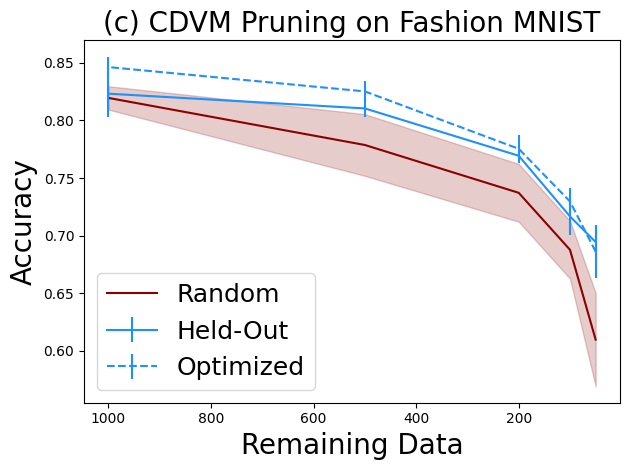

[1155.311155796051,
 1331.5084493160248,
 1573.3654639720917,
 1810.1223948001862,
 2089.3070838451385]

In [43]:
benchmark_size(train_mat, max_val=None, alpha=None, opt_func=cdvm_with_param_search, random=True, quantile=0.05)

## Benchmark: Performance vs. Matrix Sparsity

Fraction of values smaller than absolute mean: 0.6605320433333334
0.005-quantile: 0.1632080078125
Number of non-zeros: 1502651, density: 0.0050
DCP: True
DPP: True


  0%|          | 0/9 [00:00<?, ?it/s]

Training failed


 33%|███▎      | 3/9 [02:37<05:03, 50.59s/it]

Training failed


...

Training failed


 78%|███████▊  | 7/9 [31:33<06:25, 192.52s/it]

Training failed


100%|██████████| 9/9 [36:22<00:00, 242.50s/it]


Selected alpha 0.0, max_val 2.0
Time: 2183.06 sec, sum(w=1): 50, sum(w>0): 50, sum(w>.5): 50
Cumulative value: -16.44

Accuracy on unseen test set on all samples > 0.0
Number of non-zero elements: 50
0.6977200000000001 +- 0.011867333314607795 min: 0.685 max: 0.7256

Accuracy on unseen test set on 50 samples
Number of non-zero elements: 50
0.7035 +- 0.017125244523801708 min: 0.6716 max: 0.7254


Accuracy on optimized test set on all samples > 0.0
Number of non-zero elements: 50
0.6891800000000001 +- 0.02298093992855819 min: 0.6508 max: 0.7266

Accuracy on optimized test set on 50 samples
Number of non-zero elements: 50
0.6828000000000001 +- 0.020379597640777902 min: 0.6392 max: 0.7096


Integer 50 passed as W, using random
0.622128 +- 0.047165339137972905 min: 0.4898 max: 0.713


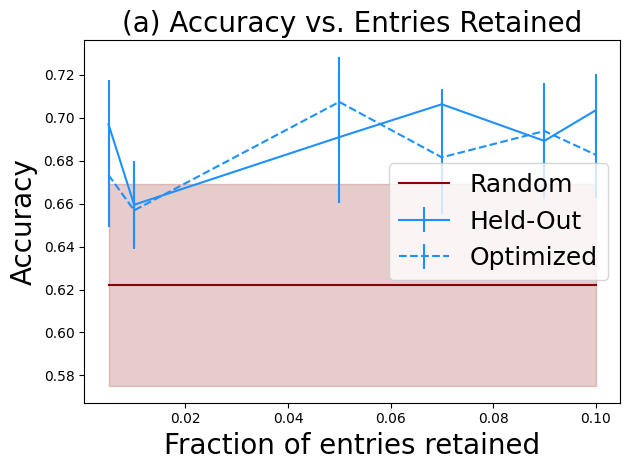

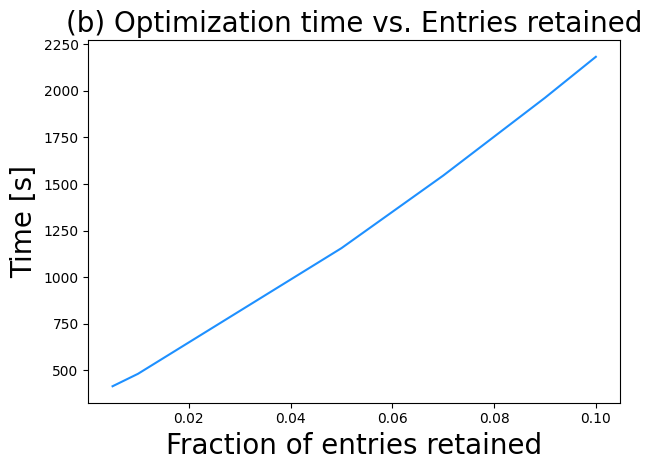

[414.200398683548,
 481.0406873226166,
 1155.7830460071564,
 1545.4290037155151,
 1962.986133813858,
 2183.0648081302643]

In [44]:
s = 50
benchmark_sparsity(train_mat, size=s, max_val=None, alpha=None, opt_func=cdvm_with_param_search, quantiles=[.005, 0.01, 0.05, 0.07, 0.09, 0.1])